<a href="https://colab.research.google.com/github/GNMoyano/InteligenciaArtificial/blob/main/Limpieza_Datos_Cr.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Analisis Exploratorio

In [ ]:
# Importaciones necesrias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

In [ ]:
#Leemos los conjuntos de datos y los concatenamos
df1 = pd.read_csv('str_1.csv', delimiter=';')
df2 = pd.read_csv('str_2.csv', delimiter=';')

df = pd.concat([df1, df2])

In [ ]:
# Visualizamos los primeros registros del conjunto de datos
df.head()

,ID,protocol,browser_type,login_attempts,duration,packet_size,encryption_used,ip_reputation_score,failed_logins,unusual_time_access,attack
0,0,TCP,Edge,4.0,492.983263,599,DES,0.606818,1,0,Y
1,1,TCP,Firefox,3.0,1557.996461,472,DES,0.301569,0,0,N
2,2,TCP,Chrome,3.0,75.044262,629,DES,0.739164,2,0,Y
3,3,UDP,Unknown,4.0,601.248835,804,DES,0.123267,0,0,Y
4,4,TCP,Firefox,5.0,532.540888,453,AES,0.054874,1,0,N


Realizamos un análisis inicial viendo:

*   Cantidad de registros
*   Variables
*   tipos
*   etc


In [ ]:
# Vemos información sobre el dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9537 entries, 0 to 7426
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   9537 non-null   int64  
 1   protocol             9537 non-null   object 
 2   browser_type         9537 non-null   object 
 3   login_attempts       9409 non-null   float64
 4   duration             9537 non-null   float64
 5   packet_size          9537 non-null   int64  
 6   encryption_used      7571 non-null   object 
 7   ip_reputation_score  9537 non-null   float64
 8   failed_logins        9537 non-null   int64  
 9   unusual_time_access  9537 non-null   int64  
 10  attack               9537 non-null   object 
dtypes: float64(3), int64(4), object(4)
memory usage: 894.1+ KB


In [ ]:
# Forma del Dataset
df.shape

(9537, 11)

El dataset tiene 9537 registros con 11 columnas

In [ ]:
# Vemos los nombres de las distintas columnas
df.columns

Index(['ID', 'protocol', 'browser_type', 'login_attempts', 'duration',
       'packet_size', 'encryption_used', 'ip_reputation_score',
       'failed_logins', 'unusual_time_access', 'attack'],
      dtype='object')

In [ ]:
# Vemos medidas de tendencia central y dispersión de las variables numericas
df.describe(include=np.number)

,ID,login_attempts,duration,packet_size,ip_reputation_score,failed_logins,unusual_time_access
count,9537.000000,9409.000000,9537.000000,9537.000000,9537.000000,9537.000000,9537.000000
mean,3124.823949,4.029971,792.745312,500.430639,0.331338,1.517773,0.149942
std,2209.075559,1.962595,786.560144,198.379364,0.177175,1.033988,0.357034
min,0.000000,1.000000,0.500000,64.000000,0.002497,0.000000,0.000000
25%,1192.000000,3.000000,231.953006,365.000000,0.191946,1.000000,0.000000
50%,2658.000000,4.000000,556.277457,499.000000,0.314778,1.000000,0.000000
75%,5042.000000,5.000000,1105.380602,635.000000,0.453388,2.000000,0.000000
max,7426.000000,13.000000,7190.392213,1285.000000,0.924299,5.000000,1.000000


In [ ]:
df.describe(include='object')

,protocol,browser_type,encryption_used,attack
count,9537,9537,7571,9537
unique,3,5,2,2
top,TCP,Chrome,AES,N
freq,6624,5137,4706,5273


Vemos que la columna loging_Attemps y la columna encryption_used tiene valores faltantes

In [ ]:
df.isnull().sum()

,0
ID,0
protocol,0
browser_type,0
login_attempts,128
duration,0
packet_size,0
encryption_used,1966
ip_reputation_score,0
failed_logins,0
unusual_time_access,0


In [ ]:
# Analizamos las filas con valores faltantes de la columna loging_Attemps
df[pd.isnull(df.login_attempts)]

,ID,protocol,browser_type,login_attempts,duration,packet_size,encryption_used,ip_reputation_score,failed_logins,unusual_time_access,attack
78,78,UDP,Chrome,NaN,195.410180,518,AES,0.447209,0,0,Y
97,97,TCP,Firefox,NaN,33.652804,552,AES,0.311972,0,0,N
126,126,TCP,Firefox,NaN,183.719758,301,AES,0.263931,2,0,N
132,132,TCP,Chrome,NaN,102.388924,287,NaN,0.063839,1,0,Y
155,155,TCP,Edge,NaN,72.910813,357,DES,0.199537,2,0,Y
...,...,...,...,...,...,...,...,...,...,...,...
6910,6910,TCP,Edge,NaN,640.488738,537,DES,0.674310,3,0,Y
6911,6911,UDP,Edge,NaN,1456.765115,821,AES,0.427167,1,1,N
6934,6934,TCP,Firefox,NaN,22.106746,439,AES,0.809237,2,0,Y
7054,7054,TCP,Unknown,NaN,898.844146,687,NaN,0.137867,0,0,N


In [ ]:
# Analizamos ls filas con valores faltantes de la columna encryption_used
df[pd.isnull(df.encryption_used)]

,ID,protocol,browser_type,login_attempts,duration,packet_size,encryption_used,ip_reputation_score,failed_logins,unusual_time_access,attack
8,8,TCP,Chrome,2.0,542.558895,406,NaN,0.294580,0,1,N
9,9,UDP,Chrome,6.0,531.944107,608,NaN,0.424117,1,0,N
12,12,TCP,Safari,2.0,186.147638,548,NaN,0.406899,2,1,N
14,14,TCP,Chrome,3.0,77.849952,155,NaN,0.352476,3,0,Y
17,17,UDP,Firefox,1.0,87.641002,562,NaN,0.136729,2,0,N
...,...,...,...,...,...,...,...,...,...,...,...
7406,7406,TCP,Chrome,4.0,199.992299,869,NaN,0.574007,1,0,N
7419,7419,TCP,Chrome,1.0,2487.078455,469,NaN,0.497153,0,0,N
7420,7420,UDP,Chrome,5.0,1037.597568,661,NaN,0.613622,3,0,Y
7423,7423,TCP,Chrome,3.0,182.848475,380,NaN,0.408485,0,0,N


In [ ]:
# Eliminamos las filas que tienen estos valores nulos
df = df.dropna()

In [ ]:
df.isnull().sum()

,0
ID,0
protocol,0
browser_type,0
login_attempts,0
duration,0
packet_size,0
encryption_used,0
ip_reputation_score,0
failed_logins,0
unusual_time_access,0


## Gráficos

Vemos algunos gráficos de las variables

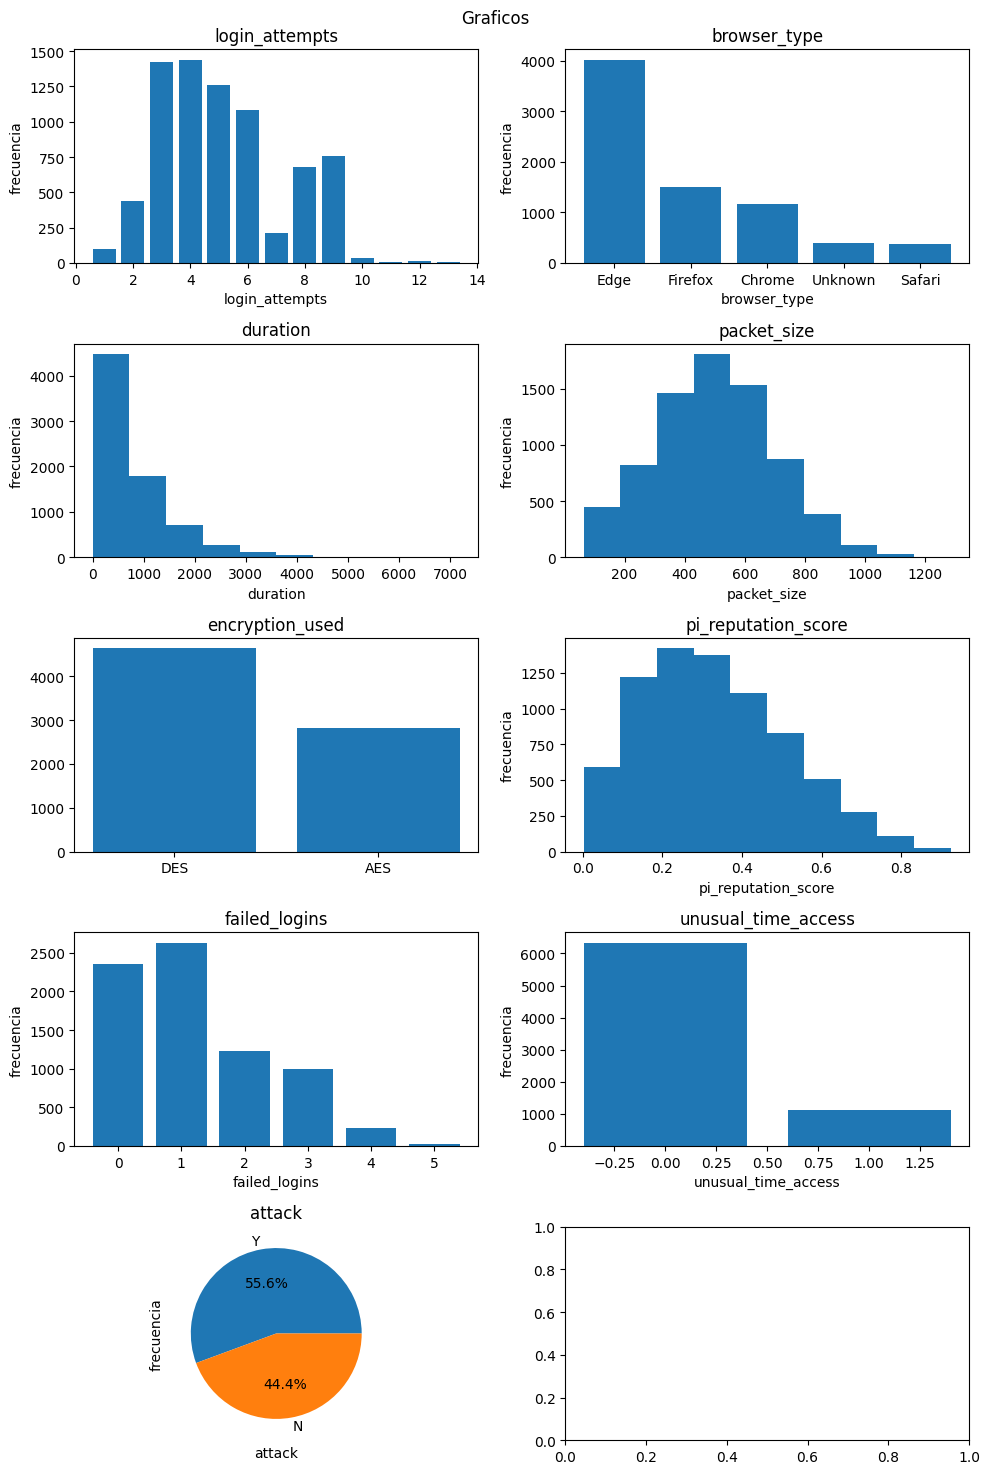

In [ ]:
fig, ax = plt.subplots(5, 2)
fig.set_figheight(15)
fig.set_figwidth(10)
fig.suptitle('Graficos')

# Columna 'login_attemps'
ax[0,0].bar(df.login_attempts.unique(), df.login_attempts.value_counts())
ax[0,0].set_title('login_attempts')
ax[0,0].set_xlabel('login_attempts')
ax[0,0].set_ylabel('frecuencia')

# Columna 'browser_type'
ax[0,1].bar(df.browser_type.unique(), df.browser_type.value_counts())
ax[0,1].set_title('browser_type')
ax[0,1].set_xlabel('browser_type')
ax[0,1].set_ylabel('frecuencia')

# Columna 'duration' boxplot
ax[1,0].hist(df.duration)
ax[1,0].set_title('duration')
ax[1,0].set_xlabel('duration')
ax[1,0].set_ylabel('frecuencia')

# Columna 'packet_size'
ax[1,1].hist(df.packet_size)
ax[1,1].set_title('packet_size')
ax[1,1].set_xlabel('packet_size')
ax[1,1].set_ylabel('frecuencia')

# Columna 'encryption_used' bar
ax[2,0].bar(df.encryption_used.unique(), df.encryption_used.value_counts())
ax[2,0].set_title('encryption_used')


# Columna 'pi_reputation_score'
ax[2,1].hist(df.ip_reputation_score)
ax[2,1].set_title('pi_reputation_score')
ax[2,1].set_xlabel('pi_reputation_score')
ax[2,1].set_ylabel('frecuencia')

# Columna 'failed_logins'
ax[3,0].bar(df.failed_logins.unique(), df.failed_logins.value_counts())
ax[3,0].set_title('failed_logins')
ax[3,0].set_xlabel('failed_logins')
ax[3,0].set_ylabel('frecuencia')

# Columna 'unusual_time_access'
ax[3,1].bar(df.unusual_time_access.unique(), df.unusual_time_access.value_counts())
ax[3,1].set_title('unusual_time_access')
ax[3,1].set_xlabel('unusual_time_access')
ax[3,1].set_ylabel('frecuencia')

# Columna 'attack'
ax[4,0].pie(df.attack.value_counts(), labels=df.attack.unique(), autopct='%1.1f%%')
ax[4,0].set_title('attack')
ax[4,0].set_xlabel('attack')
ax[4,0].set_ylabel('frecuencia')


plt.tight_layout()
plt.show()


# Procesamiento de Datos

## Analisis de las variables


Eliminamos la columna de ID ya que no aporta información relevante al modelo

In [ ]:
df = df.drop('ID', axis=1)

In [ ]:
df.head()

,protocol,browser_type,login_attempts,duration,packet_size,encryption_used,ip_reputation_score,failed_logins,unusual_time_access,attack
0,TCP,Edge,4.0,492.983263,599,DES,0.606818,1,0,Y
1,TCP,Firefox,3.0,1557.996461,472,DES,0.301569,0,0,N
2,TCP,Chrome,3.0,75.044262,629,DES,0.739164,2,0,Y
3,UDP,Unknown,4.0,601.248835,804,DES,0.123267,0,0,Y
4,TCP,Firefox,5.0,532.540888,453,AES,0.054874,1,0,N


## Valores atípicos

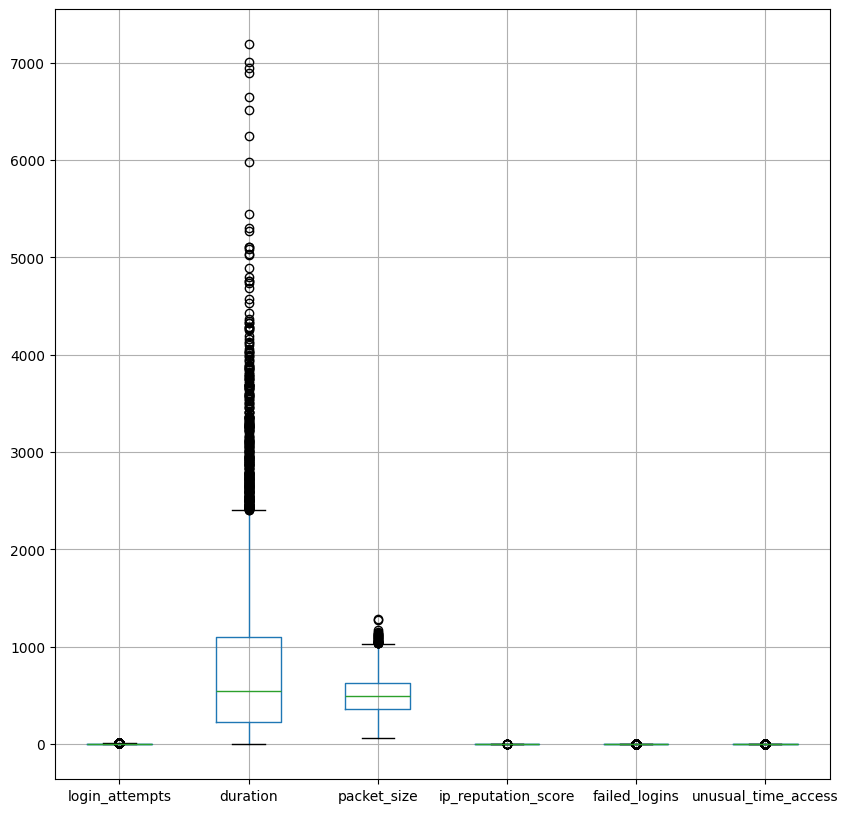

In [ ]:
# Boxplot para visualizar valores atípicos
df.boxplot(figsize=(10,10))
plt.show()

Se ven varios valores atipicos en las variables númericas, procedemos reemplazar por la mediana esos valores

<ipython-input-18-9f5958da8c7a>:10: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '419.6081949651848' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[df['packet_size'] > mean_value, 'packet_size'] = mean_value


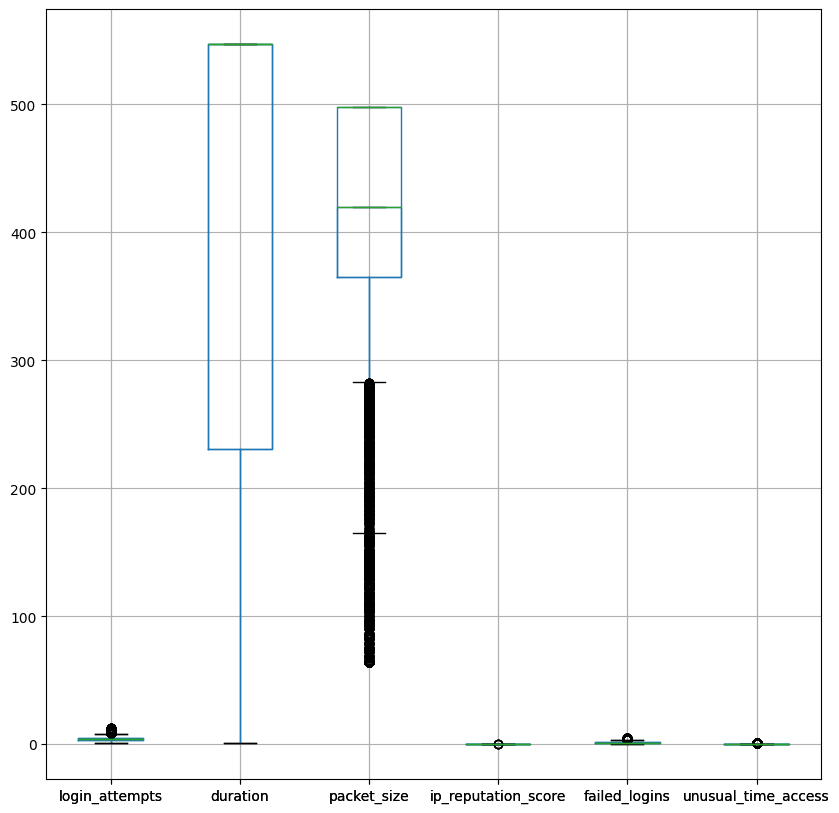

In [ ]:
# Reemplazar los valores atipicos de las columnas 'duration' y 'ip reputation_score' por la Mediana (percentil 50)
columns = ['duration','packet_size','ip_reputation_score']
for col in columns:
  median_value = np.median(df[col])
  df.loc[df[col] > median_value, col] = median_value
df.boxplot(figsize=(10,10))

# Reemplazar los valores atipicos de la columna 'packet_size' por la media
mean_value = np.mean(df['packet_size'])
df.loc[df['packet_size'] > mean_value, 'packet_size'] = mean_value
df.boxplot(figsize=(10,10))
plt.show()

## Procesamiento de variables categóricas

In [ ]:
# Vemos las variables categoricas
df.describe(include='object')

,protocol,browser_type,encryption_used,attack
count,7468,7468,7468,7468
unique,3,5,2,2
top,TCP,Chrome,AES,N
freq,5166,4021,4643,4154


Utilizamos unique para conocer los valores de las variables categoricas para las columnas 'protocol', 'browser_type', 'encryption_used' y 'attack' que esta última es nuestra variable de salida.

In [ ]:
df['protocol'].unique()

array(['TCP', 'UDP', 'ICMP'], dtype=object)

In [ ]:
df['browser_type'].unique()

array(['Edge', 'Firefox', 'Chrome', 'Unknown', 'Safari'], dtype=object)

In [ ]:
df['encryption_used'].unique()

array(['DES', 'AES'], dtype=object)

In [ ]:
df['attack'].unique()

array(['Y', 'N'], dtype=object)

In [ ]:
df['attack'].value_counts()

,count
attack,
N,4154
Y,3314


In [ ]:
# Adaptamos las variables categóricas de texto a categorías numéricas
def label_encoding(df):
    for col in df.columns:
        if df[col].dtype == 'object':
                label_encoder = LabelEncoder()
                df[col] = label_encoder.fit_transform(df[col])

label_encoding(df)

In [ ]:
df

,protocol,browser_type,login_attempts,duration,packet_size,encryption_used,ip_reputation_score,failed_logins,unusual_time_access,attack
0,1,1,4.0,492.983263,419.608195,1,0.313436,1,0,1
1,1,2,3.0,547.003307,419.608195,1,0.301569,0,0,0
2,1,0,3.0,75.044262,419.608195,1,0.313436,2,0,1
3,2,4,4.0,547.003307,419.608195,1,0.123267,0,0,1
4,1,2,5.0,532.540888,419.608195,0,0.054874,1,0,0
...,...,...,...,...,...,...,...,...,...,...
7418,1,1,7.0,50.518476,419.608195,1,0.313436,1,1,1
7421,1,0,7.0,315.151758,419.608195,1,0.190059,3,0,1
7422,0,0,3.0,226.049889,194.000000,0,0.313436,3,0,1
7424,1,2,5.0,35.170248,419.608195,0,0.313436,1,0,0


## Correlación entre variables

In [ ]:
# Calculamos todos los coeficientes de correlacion
corr= df.corr(numeric_only=True)
corr

,protocol,browser_type,login_attempts,duration,packet_size,encryption_used,ip_reputation_score,failed_logins,unusual_time_access,attack
protocol,1.000000,0.013559,0.022324,-0.010446,0.007005,-0.002261,0.030341,-0.007393,0.005584,0.009062
browser_type,0.013559,1.000000,-0.001901,0.002042,0.015387,-0.006564,0.010319,0.002365,-0.013308,0.087607
login_attempts,0.022324,-0.001901,1.000000,0.014491,0.004470,0.004777,0.010923,-0.018892,0.018889,0.276372
duration,-0.010446,0.002042,0.014491,1.000000,0.008580,-0.011825,-0.001815,0.007321,-0.001856,0.007496
packet_size,0.007005,0.015387,0.004470,0.008580,1.000000,0.009047,-0.008320,-0.016249,-0.003273,-0.010890
encryption_used,-0.002261,-0.006564,0.004777,-0.011825,0.009047,1.000000,-0.018198,0.002450,-0.000540,0.016327
ip_reputation_score,0.030341,0.010319,0.010923,-0.001815,-0.008320,-0.018198,1.000000,0.014286,0.000619,0.095314
failed_logins,-0.007393,0.002365,-0.018892,0.007321,-0.016249,0.002450,0.014286,1.000000,0.009861,0.367443
unusual_time_access,0.005584,-0.013308,0.018889,-0.001856,-0.003273,-0.000540,0.000619,0.009861,1.000000,0.006351
attack,0.009062,0.087607,0.276372,0.007496,-0.010890,0.016327,0.095314,0.367443,0.006351,1.000000


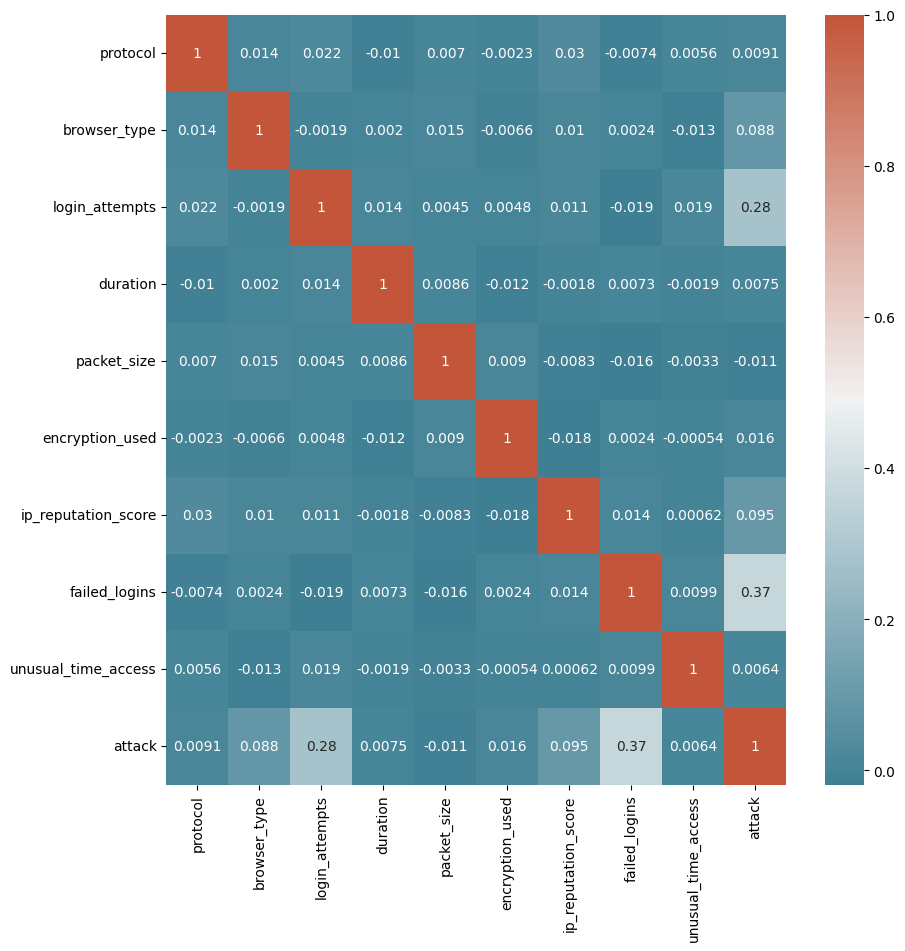

In [ ]:
# Visualizamos la matriz de correlacion
plt.figure(figsize=(10,10))
sns.heatmap(corr, xticklabels=corr.columns, yticklabels=corr.columns, annot=True, cmap=sns.diverging_palette(220, 20, as_cmap=True))
plt.show()

Tienen una correlacion muy baja todas las varriables, por lo que no hay necesidad de eliminar variables

## Balance del conjunto de datos

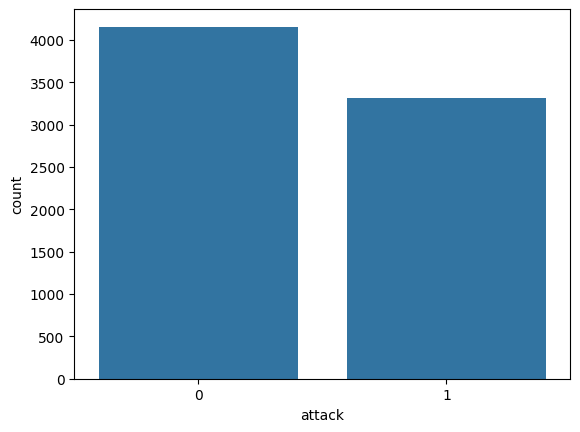

In [ ]:
# Visualizar el balance del dataset
sns.countplot(x='attack', data=df)
plt.show()

La variable attack esta desbalanceada por lo que optamos por hacer un UnderSample para disminuir la cantidad de muestras de la clase mayoritaria

In [ ]:
# Seleccionar las columnas del dataset que corresponden a
# las entradas del modelo y la salida esperada
X = df.drop('attack', axis=1)
y = df['attack']

In [ ]:
# Importar el paquete imblearn para underSampling
from imblearn.under_sampling import RandomUnderSampler

In [ ]:
# Generar un nuevos conjunto de datos balanceado por Under-Sampling
undersampling = RandomUnderSampler(random_state=42)
X_under, y_under = undersampling.fit_resample(X, y)

<Axes: xlabel='attack', ylabel='count'>

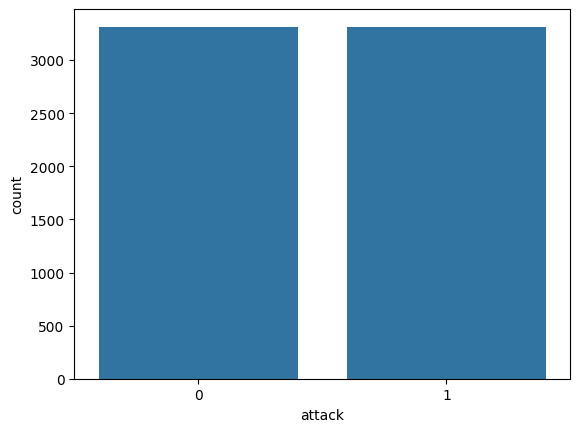

In [ ]:
# Visualizamos el balance del dataset generado
sns.countplot(x=y_under)

## Normalización

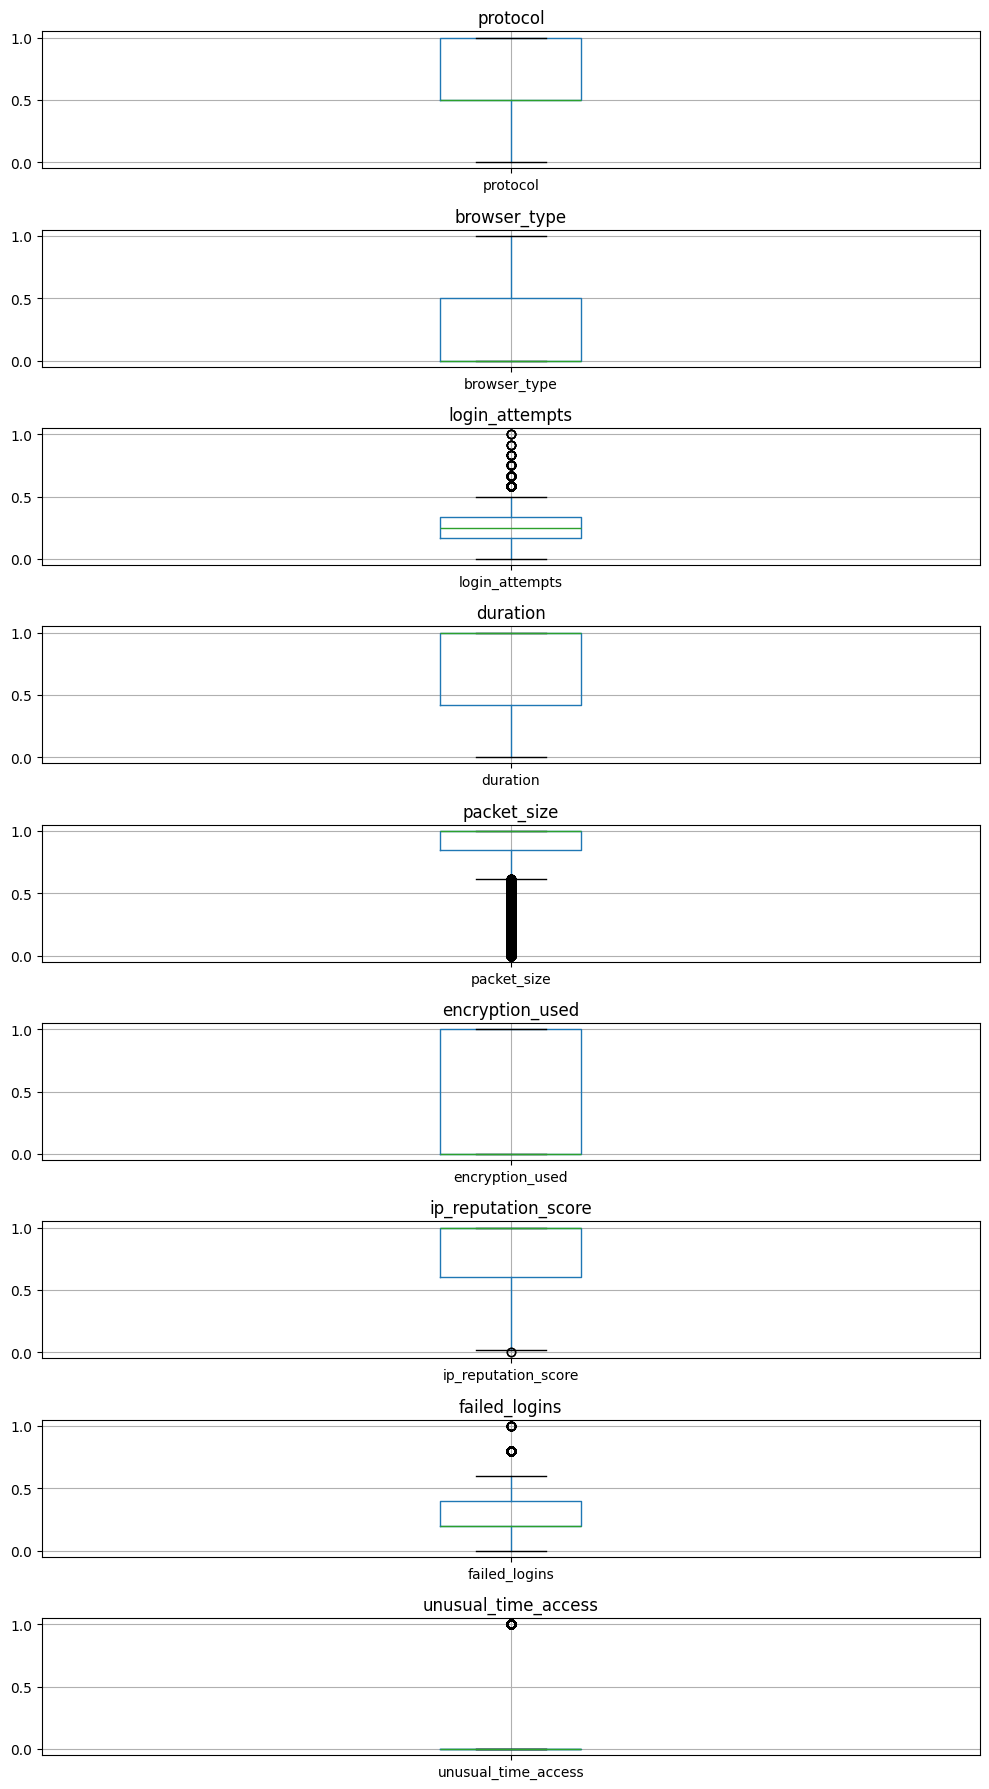

In [ ]:
# Copiar el dataset a otra variable
df_normal = df.copy()

# Normalizamos
columns = ['protocol', 'browser_type', 'login_attempts','duration','packet_size','encryption_used','ip_reputation_score','failed_logins', 'unusual_time_access']
for col in columns:
    df_normal[col] = (df_normal[col] - df_normal[col].min()) / (df_normal[col].max() - df_normal[col].min())
# Visualizamos la distribucion nueva de las variables
fig, ax = plt.subplots(len(columns), 1, figsize=(10, 2 * len(columns))) # Adjust figsize as needed

for i, col in enumerate(columns):
    df_normal.boxplot(column=col, ax=ax[i])
    ax[i].set_title(col)

plt.tight_layout()
plt.show()

